import library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

# load data

In [2]:
df = pd.read_csv('results.csv')

print("shape:", df.shape)
df.head()

shape: (49287, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [3]:
df.info

<bound method DataFrame.info of              date home_team   away_team  home_score  away_score  \
0      1872-11-30  Scotland     England         0.0         0.0   
1      1873-03-08   England    Scotland         4.0         2.0   
2      1874-03-07  Scotland     England         2.0         1.0   
3      1875-03-06   England    Scotland         2.0         2.0   
4      1876-03-04  Scotland     England         3.0         0.0   
...           ...       ...         ...         ...         ...   
49282  2026-06-27    Jordan   Argentina         NaN         NaN   
49283  2026-06-27  Colombia    Portugal         NaN         NaN   
49284  2026-06-27  DR Congo  Uzbekistan         NaN         NaN   
49285  2026-06-27    Panama     England         NaN         NaN   
49286  2026-06-27   Croatia       Ghana         NaN         NaN   

           tournament             city        country  neutral  
0            Friendly          Glasgow       Scotland    False  
1            Friendly           London        England    False  
2            Friendly          Glasgow       Scotland    False  
3            Friendly           London        England    False  
4            Friendly          Glasgow       Scotland    False  
...               ...              ...            ...      ...  
49282  FIFA World Cup        Arlington  United States     True  
49283  FIFA World Cup    Miami Gardens  United States     True  
49284  FIFA World Cup          Atlanta  United States     True  
49285  FIFA World Cup  East Rutherford  United States     True  
49286  FIFA World Cup     Philadelphia  United States     True  

[49287 rows x 9 columns]>

cek semua missing values

In [4]:
print("missing values:")
print(df.isnull().sum())

missing values:
date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64


cek unique tournament

In [5]:
df['tournament'].value_counts().head()

,count
tournament,
Friendly,18252
FIFA World Cup qualification,8771
UEFA Euro qualification,2824
African Cup of Nations qualification,2327
FIFA World Cup,1036


# Data cleaning

In [6]:
# convert date
df['date'] = pd.to_datetime(df['date'])

# buat fitur tahun
df['year'] = df['date'].dt.year

df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,1872
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,1873
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,1874
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,1875
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,1876


In [7]:
# cek missing
print(df[['home_score', 'away_score']].isnull().sum())

# drop baris yang missing di kolom penting
df = df.dropna(subset=['home_score', 'away_score'])

print("After drop:", df.shape)

home_score    72
away_score    72
dtype: int64
After drop: (49215, 10)


In [8]:
print("Missing after cleaning:")
print(df[['home_score', 'away_score']].isnull().sum())

Missing after cleaning:
home_score    0
away_score    0
dtype: int64


# Create target (hasil match)

In [9]:
#create target
def get_result(row):
    if row['home_score'] > row['away_score']:
        return 'HomeWin'
    elif row['home_score'] < row['away_score']:
        return 'AwayWin'
    else:
        return 'Draw'

df['result'] = df.apply(get_result, axis=1)

df['result'].value_counts()

,count
result,
HomeWin,24106
AwayWin,13912
Draw,11197


hapus data leakage

In [10]:
df = df.drop(columns=['home_score', 'away_score'])

# Recent form

In [11]:
df_full = pd.read_csv('results.csv')
df_full = df_full.dropna(subset=['home_score', 'away_score'])

df_full['date'] = pd.to_datetime(df_full['date'])
df_full = df_full.sort_values('date')

result numeric

In [12]:
def get_result_numeric(row):
    if row['home_score'] > row['away_score']:
        return 1
    elif row['home_score'] < row['away_score']:
        return -1
    else:
        return 0

df_full['result_numeric'] = df_full.apply(get_result_numeric, axis=1)

recent form function

In [13]:
def compute_recent_form(df, team_col, score_col_for, score_col_against):
    teams = df[team_col].unique()

    form_dict = {}

    for team in teams:
        team_matches = df[df[team_col] == team].copy()
        team_matches = team_matches.sort_values('date')

        results = team_matches['result_numeric'].rolling(5).mean()
        goals_for = team_matches[score_col_for].rolling(5).mean()
        goals_against = team_matches[score_col_against].rolling(5).mean()

        form_dict[team] = pd.DataFrame({
            'form': results,
            'goals_for': goals_for,
            'goals_against': goals_against
        }, index=team_matches.index)

    return form_dict

hitung form home dan away

In [14]:
home_form = compute_recent_form(df_full, 'home_team', 'home_score', 'away_score')
away_form = compute_recent_form(df_full, 'away_team', 'away_score', 'home_score')

apply recent form ke dataset utama

In [15]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# initialize kolom
df['home_form'] = 0
df['away_form'] = 0
df['home_goals_avg'] = 0
df['away_goals_avg'] = 0

for i, row in df.iterrows():
    team_h = row['home_team']
    team_a = row['away_team']

    if team_h in home_form and i in home_form[team_h].index:
        df.loc[i, 'home_form'] = home_form[team_h].loc[i, 'form']
        df.loc[i, 'home_goals_avg'] = home_form[team_h].loc[i, 'goals_for']

    if team_a in away_form and i in away_form[team_a].index:
        df.loc[i, 'away_form'] = away_form[team_a].loc[i, 'form']
        df.loc[i, 'away_goals_avg'] = away_form[team_a].loc[i, 'goals_for']

# fill missing
df[['home_form','away_form']] = df[['home_form','away_form']].fillna(0)

In [16]:
df['form_diff'] = df['home_form'] - df['away_form']
df['goals_avg_diff'] = df['home_goals_avg'] - df['away_goals_avg']

# Feature engineering (win rate)

In [17]:
# reload data untuk statistik historis
df_temp = pd.read_csv('results.csv')
df_temp = df_temp.dropna(subset=['home_score', 'away_score'])

def get_result_numeric(row):
    if row['home_score'] > row['away_score']:
        return 1
    elif row['home_score'] < row['away_score']:
        return -1
    else:
        return 0

df_temp['result_numeric'] = df_temp.apply(get_result_numeric, axis=1)

In [18]:
# hitung win rate
home_win_rate = df_temp.groupby('home_team')['result_numeric'].mean().to_dict()
away_win_rate = df_temp.groupby('away_team')['result_numeric'].mean().to_dict()

In [19]:
# mapping ke dataset utama
df['home_win_rate'] = df['home_team'].map(home_win_rate)
df['away_win_rate'] = df['away_team'].map(away_win_rate)

In [20]:
# handle missing
df['home_win_rate'] = df['home_win_rate'].fillna(0)
df['away_win_rate'] = df['away_win_rate'].fillna(0)

In [21]:
# feature penting
df['win_rate_diff'] = df['home_win_rate'] - df['away_win_rate']

goal stats

In [22]:
# rata-rata gol tim (home)
team_avg_goal_home = df_temp.groupby('home_team')['home_score'].mean().to_dict()

# rata-rata gol tim (away)
team_avg_goal_away = df_temp.groupby('away_team')['away_score'].mean().to_dict()

# mapping
df['home_avg_goal'] = df['home_team'].map(team_avg_goal_home)
df['away_avg_goal'] = df['away_team'].map(team_avg_goal_away)

# handle missing
df['home_avg_goal'] = df['home_avg_goal'].fillna(df['home_avg_goal'].mean())
df['away_avg_goal'] = df['away_avg_goal'].fillna(df['away_avg_goal'].mean())

# difference (penting)
df['goal_avg_diff'] = df['home_avg_goal'] - df['away_avg_goal']

drop date sebelum split

In [23]:
df['year'] = df['date'].dt.year
df = df.drop(columns=['date'])

# Encoding

In [24]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

categorical_cols = ['home_team', 'away_team', 'tournament', 'city', 'country', 'neutral']

df_model = pd.get_dummies(df_model, columns=categorical_cols)

# encode target
le = LabelEncoder()
df_model['result'] = le.fit_transform(df_model['result'])

cek imbalance

In [25]:
print("Distribusi label:")
print(df['result'].value_counts())

print("\nDistribusi (%):")
print(df['result'].value_counts(normalize=True))

Distribusi label:
result
HomeWin    24106
AwayWin    13912
Draw       11197
Name: count, dtype: int64

Distribusi (%):
result
HomeWin    0.489810
AwayWin    0.282678
Draw       0.227512
Name: proportion, dtype: float64


# Split data

In [26]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['result'])
y = df_model['result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (39372, 3252)
Test: (9843, 3252)


cek data

In [27]:
print("Jumlah NaN di X_train:", X_train.isnull().sum().sum())

Jumlah NaN di X_train: 3547


handle NaN

In [28]:
# isi semua NaN dengan 0
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

Handle imbalance (smote)

In [29]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", y_train.value_counts())

After SMOTE: result
0    19285
2    19285
1    19285
Name: count, dtype: int64


# Train model

In [30]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=300, max_depth=20, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=20, n_estimators=300,
                       random_state=42)

# Evaluation

In [31]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.6420806664634766

Classification Report:

              precision    recall  f1-score   support

           0       0.63      0.71      0.67      2783
           1       0.37      0.28      0.32      2239
           2       0.74      0.77      0.76      4821

    accuracy                           0.64      9843
   macro avg       0.58      0.59      0.58      9843
weighted avg       0.63      0.64      0.63      9843



# Confusion matrix

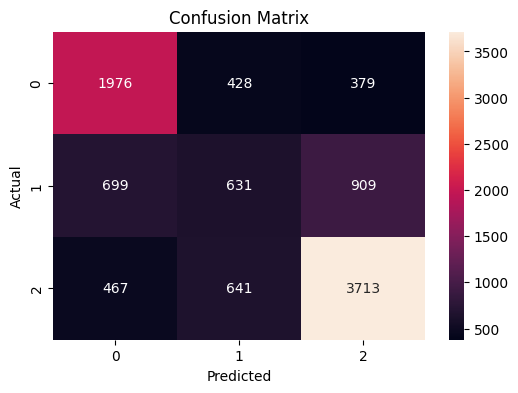

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

save model

In [33]:
import joblib

joblib.dump(model, "worldcup_model.pkl")
joblib.dump(X.columns, "columns.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']